<a href="https://colab.research.google.com/github/mdkamrulhasan/data_mining_kdd/blob/main/notebooks/Diabetes_EDA_Feature_Selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **LOADING LIBRARIES**

In [1]:
#Loading libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# **DATA IMPORTATION**

In [2]:
#Loading the dataset

# diabetes = pd.read_csv("/content/diabetes_data.csv")

In [3]:
diabetes = pd.read_csv("https://raw.githubusercontent.com/mdkamrulhasan/data_mining_kdd/main/data/diabetes/diabetes_data.csv", encoding='unicode_escape')

# **EXPLORATORY DATA ANALYSIS(EDA)**

In [4]:
#nspecting the first five rows of the dataset

diabetes.head()

,Age,Sex,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Stroke,HighBP,Diabetes
0,4.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,5.0,30.0,0.0,0.0,1.0,0.0
1,12.0,1.0,1.0,1.0,26.0,1.0,0.0,0.0,1.0,0.0,0.0,3.0,0.0,0.0,0.0,1.0,1.0,0.0
2,13.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,10.0,0.0,0.0,0.0,0.0
3,11.0,1.0,1.0,1.0,28.0,1.0,0.0,1.0,1.0,1.0,0.0,3.0,0.0,3.0,0.0,0.0,1.0,0.0
4,8.0,0.0,0.0,1.0,29.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
diabetes.info()

In [10]:
#converting variables to correct datatypes

diabetes['Age'] = diabetes['Age'].astype(int)
diabetes['Sex'] = diabetes['Sex'].astype(int)
diabetes['HighChol'] = diabetes['HighChol'].astype(int)
diabetes['CholCheck'] = diabetes['CholCheck'].astype(int)
diabetes['Smoker'] = diabetes['Smoker'].astype(int)
diabetes['HeartDiseaseorAttack'] = diabetes['HeartDiseaseorAttack'].astype(int)
diabetes['PhysActivity'] = diabetes['PhysActivity'].astype(int)
diabetes['Fruits'] = diabetes['Fruits'].astype(int)
diabetes['Veggies'] = diabetes['Veggies'].astype(int)
diabetes['HvyAlcoholConsump'] = diabetes['HvyAlcoholConsump'].astype(int)
diabetes['GenHlth'] = diabetes['GenHlth'].astype(int)
diabetes['MentHlth'] = diabetes['MentHlth'].astype(int)
diabetes['PhysHlth'] = diabetes['PhysHlth'].astype(int)
diabetes['DiffWalk'] = diabetes['DiffWalk'].astype(int)
diabetes['Stroke'] = diabetes['Stroke'].astype(int)
diabetes['HighBP'] = diabetes['HighBP'].astype(int)
diabetes['Diabetes'] = diabetes['Diabetes'].astype(int)


# **CORRELATION**

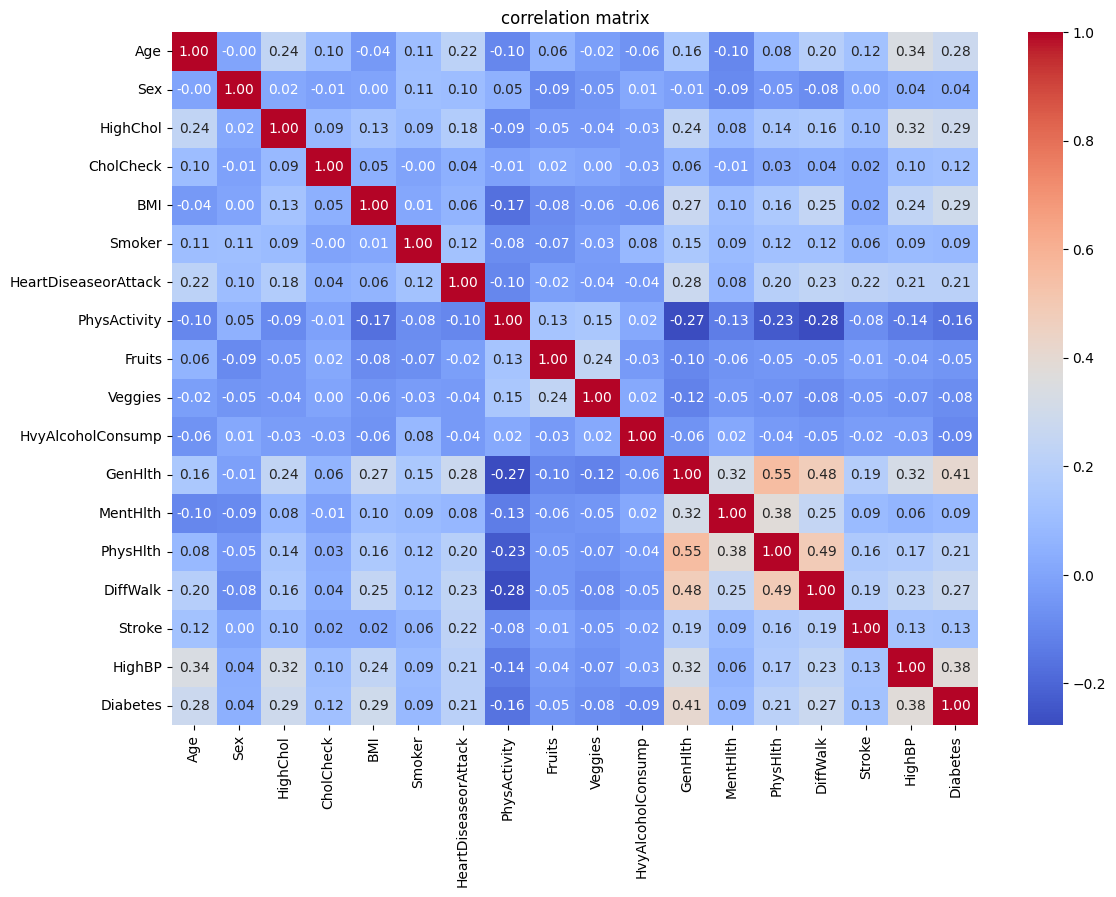

In [13]:
# Correlation studies

plt.figure(figsize = (13,9))
sns.heatmap(diabetes.corr(), annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('correlation matrix')
plt.show()

<Axes: >

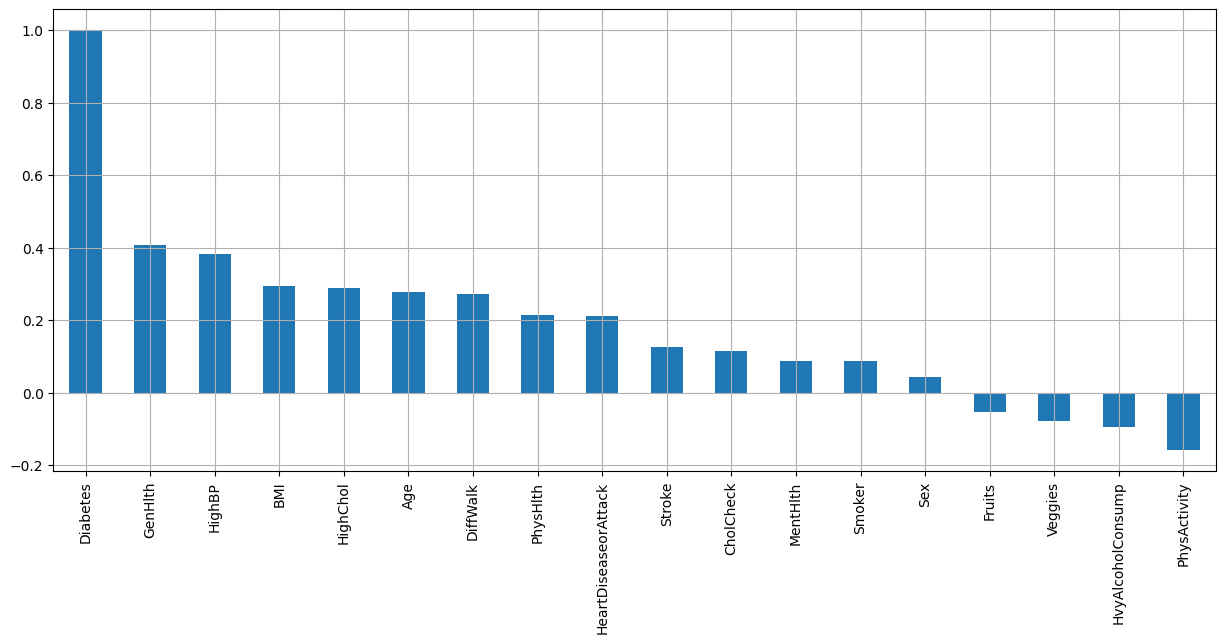

In [14]:
#Feature correlation with target variable

diabetes.corr()['Diabetes'].sort_values(ascending=False).plot(kind = 'bar', grid = True, figsize = (15, 6))

Text(0, 0.5, 'Features')

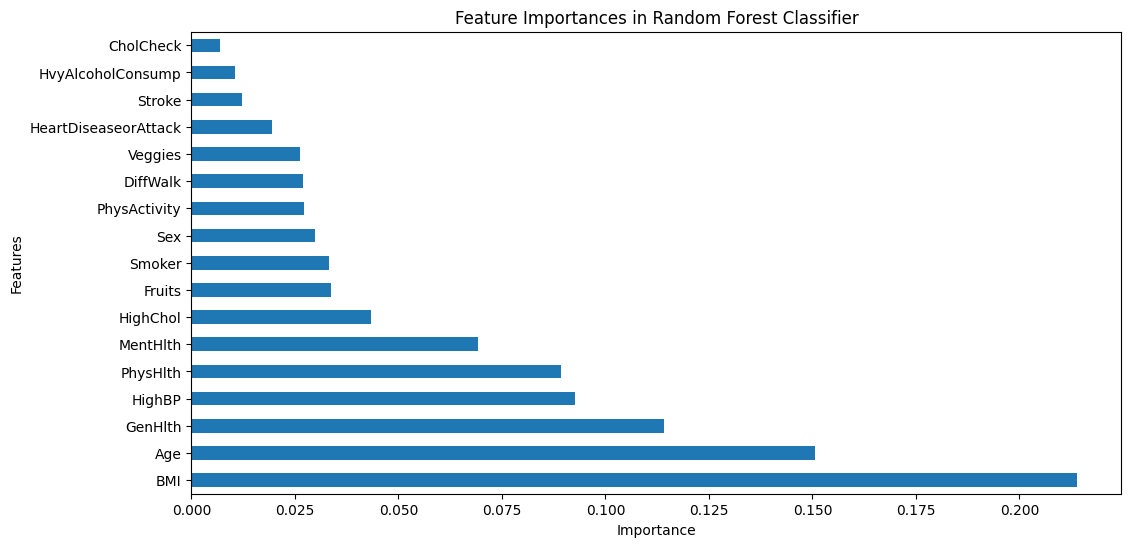

In [18]:
from sklearn.ensemble import RandomForestClassifier

#ExtractIng features and target variable
X = diabetes.drop('Diabetes', axis=1)
y = diabetes['Diabetes']

#Initialize a RandomForestClassifier
rf_classifier = RandomForestClassifier(random_state=42)

#Fit the model
rf_classifier.fit(X, y)

feature_importances = pd.Series(rf_classifier.feature_importances_, index=X.columns)
feature_importances.sort_values(ascending=False).plot(kind='barh', figsize=(12, 6))

plt.title('Feature Importances in Random Forest Classifier')
plt.xlabel('Importance')
plt.ylabel('Features')


In [19]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

k = 20
chi2_selector = SelectKBest(chi2, k=k)
X_chi2 = chi2_selector.fit_transform(X, y)

#Getting chi-squared test statistics and p-values
chi2_stats = chi2_selector.scores_
p_values = chi2_selector.pvalues_

#DataFrame displaying chi-squared statistics and p-values for each feature
chi2_df = pd.DataFrame({'Feature': X.columns, 'Chi2_Stat': chi2_stats, 'P_Value': p_values})

# Sorting features by chi-squared statistics in descending order and p-values in ascending order
chi2_df = chi2_df.sort_values(by=['Chi2_Stat', 'P_Value'], ascending=[False, True])

# Chi-squared Test for Feature Selection
print(chi2_df['Feature'])

13                PhysHlth
4                      BMI
12                MentHlth
0                      Age
11                 GenHlth
16                  HighBP
14                DiffWalk
2                 HighChol
6     HeartDiseaseorAttack
15                  Stroke
10       HvyAlcoholConsump
7             PhysActivity
5                   Smoker
9                  Veggies
8                   Fruits
1                      Sex
3                CholCheck
Name: Feature, dtype: object


/usr/local/lib/python3.13/dist-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=20 is greater than n_features=17. All the features will be returned.
  warnings.warn(


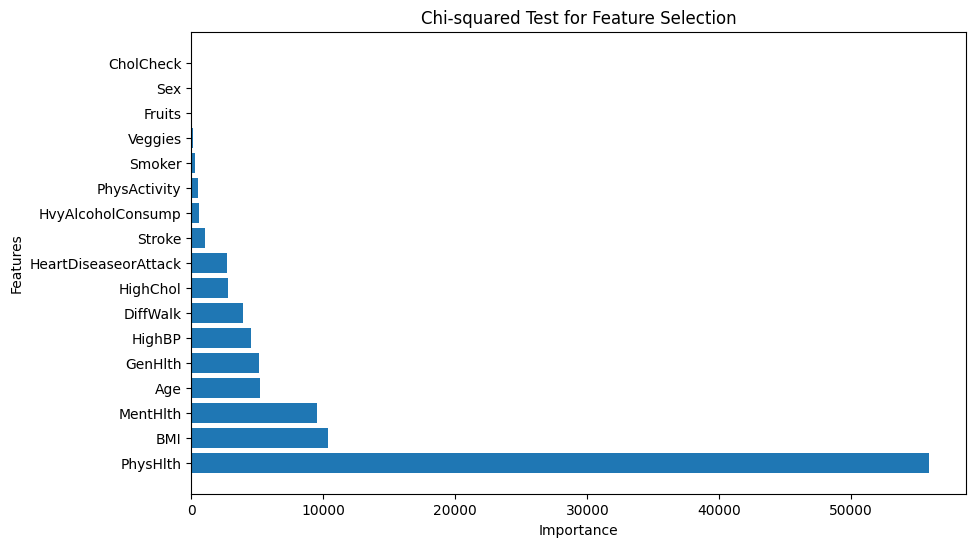

In [20]:
#Setting up the figure
plt.figure(figsize=(10, 6))

# Plotting the features
plt.barh(chi2_df['Feature'], chi2_df['Chi2_Stat'])

#Labels and Title
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Chi-squared Test for Feature Selection')

# Show the plot
plt.show()